# Exploratory Data Analysis (EDA)

Loads all CSV files from a user-defined folder and performs a structured EDA.

| Section | Content |
|---|---|
| **1. Per-File** | Descriptive stats · Kurtosis & Skewness · Histograms · Correlation matrix |
| **2. Aggregate** | Global stats on concatenated data · Cross-file summary · Aggregate histograms · Correlation matrices |

> Per-file **plots** are capped at `MAX_FILES_DISPLAY` to keep the output manageable.

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from IPython.display import display

pd.set_option('display.float_format', '{:.4f}'.format)
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')
%matplotlib inline

In [ ]:
# ── USER INPUT ────────────────────────────────────────────────────────────────
load_from_dir = "../data/SNP500_individual"  # <-- set your folder here

# Max files for which per-file PLOTS are rendered (set None to plot all files)
MAX_FILES_DISPLAY = 5

# Remove Black Monday (19 Oct 1987) rows from all loaded dataframes
remove_black_monday = True
# ─────────────────────────────────────────────────────────────────────────────

---
## 0. Data Loading

In [41]:
csv_paths = sorted(Path(load_from_dir).glob("*.csv"))
assert len(csv_paths) > 0, f"No CSV files found in '{load_from_dir}'"

dataframes = {p.stem: pd.read_csv(p, parse_dates=["date"], dayfirst=True) for p in csv_paths}
print(f"Loaded {len(dataframes)} file(s) from '{load_from_dir}'")

if remove_black_monday:
    BLACK_MONDAY = "1987-10-19"
    before = sum(len(df) for df in dataframes.values())
    dataframes = {
        name: df[df["date"] != BLACK_MONDAY].reset_index(drop=True)
        for name, df in dataframes.items()
    }
    removed = before - sum(len(df) for df in dataframes.values())
    print(f"Black Monday ({BLACK_MONDAY}) removed: {removed} row(s) dropped")

# Schema check
schemas = {name: tuple(df.columns.tolist()) for name, df in dataframes.items()}
unique_schemas = set(schemas.values())
if len(unique_schemas) == 1:
    cols = list(unique_schemas)[0]
    print(f"Shared schema ({len(cols)} columns): {cols}")
else:
    print(f"WARNING: {len(unique_schemas)} different schemas detected.")
    for schema in unique_schemas:
        count = sum(1 for v in schemas.values() if v == schema)
        print(f"  {schema}  →  {count} file(s)")

Loaded 354 file(s) from '../data/SNP500_individual'
  ('date', 'open', 'high', 'low', 'close', 'adj_close')  →  2 file(s)
  ('date', 'open', 'high', 'low', 'close')  →  352 file(s)


---
## 1. Per-File Statistics

For each CSV: descriptive statistics (mean, median, std, min, max), kurtosis, skewness, histograms, and correlation matrix.

### 1.1 Descriptive Statistics per File

In [42]:
summary_rows = []

for name, df in dataframes.items():
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    desc   = num_df.describe()
    median = num_df.median().rename('median')
    kurt   = num_df.kurtosis().rename('kurtosis')
    skew   = num_df.skew().rename('skewness')

    extended = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
    row_order = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
    extended  = extended.reindex([r for r in row_order if r in extended.index])

    print(f"\n{'─'*60}\n  {name}\n{'─'*60}")
    display(extended)

    # Collect for cross-file summary
    for col in num_df.columns:
        summary_rows.append({
            'file':     name,
            'column':   col,
            'mean':     num_df[col].mean(),
            'median':   num_df[col].median(),
            'std':      num_df[col].std(),
            'min':      num_df[col].min(),
            'max':      num_df[col].max(),
            'kurtosis': num_df[col].kurtosis(),
            'skewness': num_df[col].skew(),
        })

per_file_summary = pd.DataFrame(summary_rows)


────────────────────────────────────────────────────────────
  A_1999-11-18_2026-05-01
────────────────────────────────────────────────────────────


,open,high,low,close
count,6652.0000,6652.0000,6652.0000,6652.0000
mean,52.5621,53.2060,51.9098,52.5688
median,32.8118,33.1924,32.4086,32.8188
std,44.0728,44.5267,43.5875,44.0589
min,6.3811,6.6376,6.2619,6.4706
25%,20.0081,20.3146,19.7442,20.0434
50%,32.8118,33.1924,32.4086,32.8188
75%,73.2328,73.8908,72.2675,73.1572
max,173.3615,173.6419,171.3212,173.3615
kurtosis,-0.3733,-0.3792,-0.3697,-0.3747



────────────────────────────────────────────────────────────
  AAPL_1980-12-12_2026-05-01
────────────────────────────────────────────────────────────


,open,high,low,close
count,11438.0000,11438.0000,11438.0000,11438.0000
mean,29.6121,29.9325,29.3103,29.6342
median,0.5043,0.5160,0.4938,0.5049
std,60.8297,61.4815,60.2276,60.8810
min,0.0380,0.0380,0.0376,0.0376
25%,0.2474,0.2538,0.2416,0.2478
50%,0.5043,0.5160,0.4938,0.5049
75%,22.1165,22.2966,21.8828,22.1251
max,285.9325,288.3502,283.0352,285.9225
kurtosis,4.5873,4.5739,4.5990,4.5843



────────────────────────────────────────────────────────────
  ABBV_2013-01-02_2026-05-01
────────────────────────────────────────────────────────────


...

,open,high,low,close
count,9375.0000,9375.0000,9375.0000,9375.0000
mean,22.3660,22.6854,22.0308,22.3636
median,12.4348,12.5726,12.3199,12.4661
std,27.7381,28.1369,27.2974,27.7209
min,0.0653,0.0653,0.0653,0.0653
25%,1.8280,1.8803,1.8019,1.8411
50%,12.4348,12.5726,12.3199,12.4661
75%,25.5561,25.8642,25.3402,25.5719
max,131.6520,133.2867,131.1692,132.0686
kurtosis,1.9701,1.9625,1.9732,1.9674



────────────────────────────────────────────────────────────
  XOM_1962-01-02_2026-05-01
────────────────────────────────────────────────────────────


,open,high,low,close
count,16191.0000,16191.0000,16191.0000,16191.0000
mean,22.2170,22.4299,22.0063,22.2238
median,5.6959,5.7352,5.6546,5.6986
std,29.5009,29.7878,29.2196,29.5108
min,0.0826,0.0871,0.0815,0.0826
25%,0.3836,0.3865,0.3810,0.3835
50%,5.6959,5.7352,5.6546,5.6986
75%,40.3086,40.9768,39.8044,40.4131
max,172.6700,176.4100,171.0500,171.4700
kurtosis,2.3935,2.4188,2.3704,2.3959



────────────────────────────────────────────────────────────
  XYZ_2015-11-19_2026-05-01
────────────────────────────────────────────────────────────


,open,high,low,close
count,2626.0000,2626.0000,2626.0000,2626.0000
mean,80.1532,81.8870,78.3341,80.1075
median,65.8775,67.0750,64.7500,65.9150
std,62.1500,63.3903,60.6924,61.9945
min,8.2700,8.6000,8.0610,8.3700
25%,50.3175,51.7825,48.9300,50.4325
50%,65.8775,67.0750,64.7500,65.9150
75%,80.9475,82.5075,79.3100,80.8775
max,280.0100,289.2300,273.5900,281.8100
kurtosis,1.9651,1.9330,2.0275,1.9801


### 1.2 Per-File Histograms
> Limited to the first `MAX_FILES_DISPLAY` files.

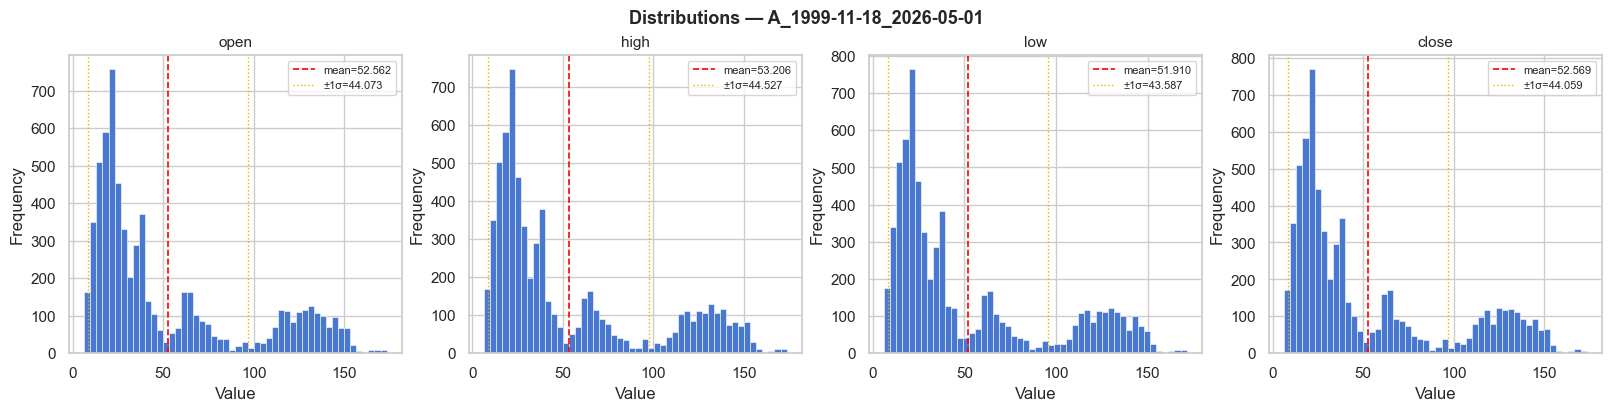

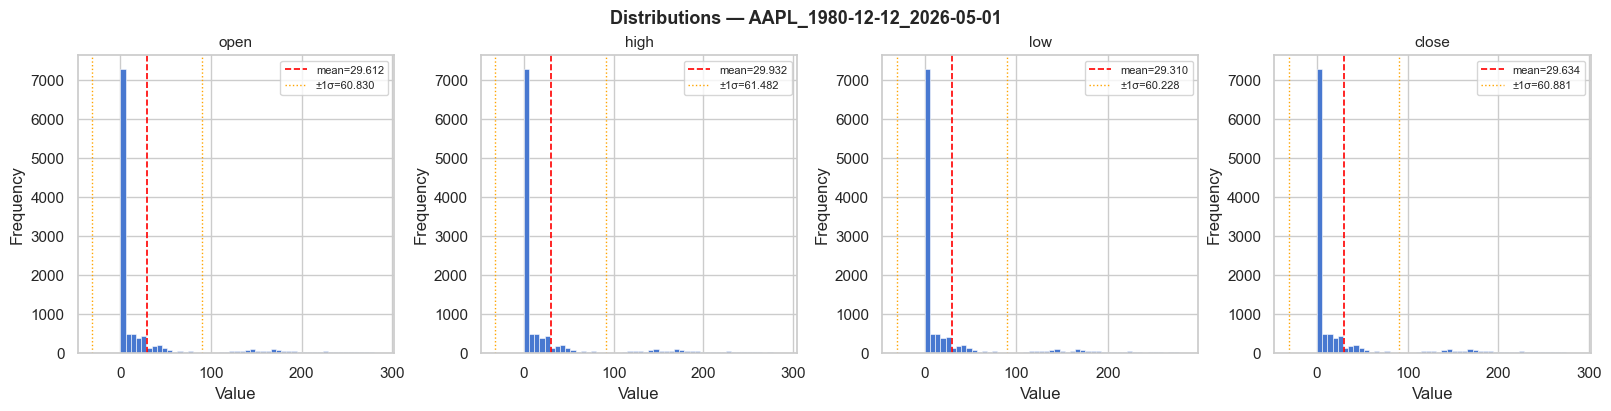

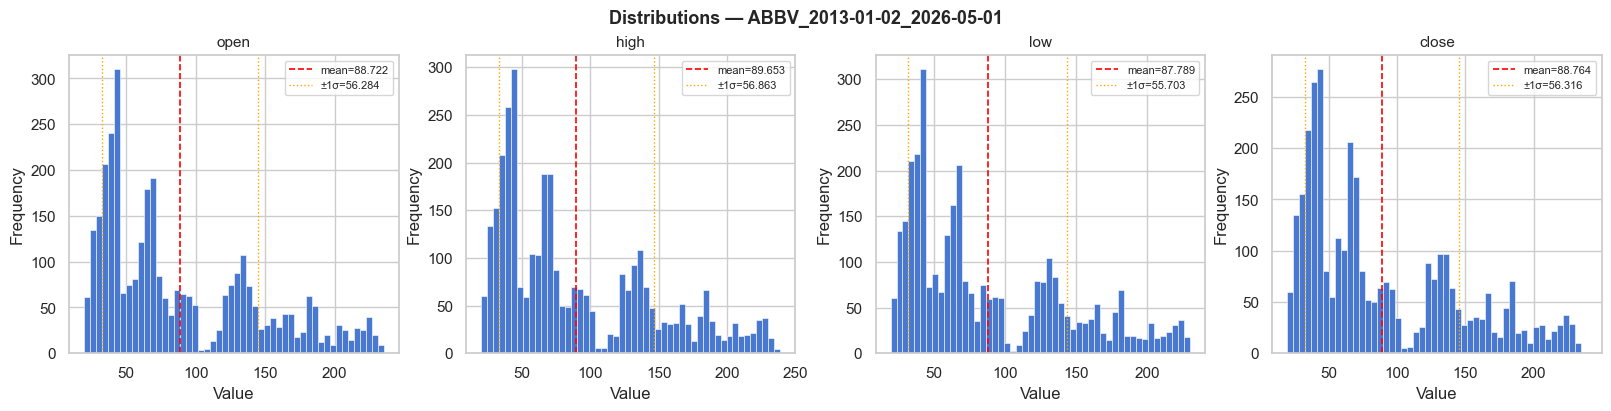

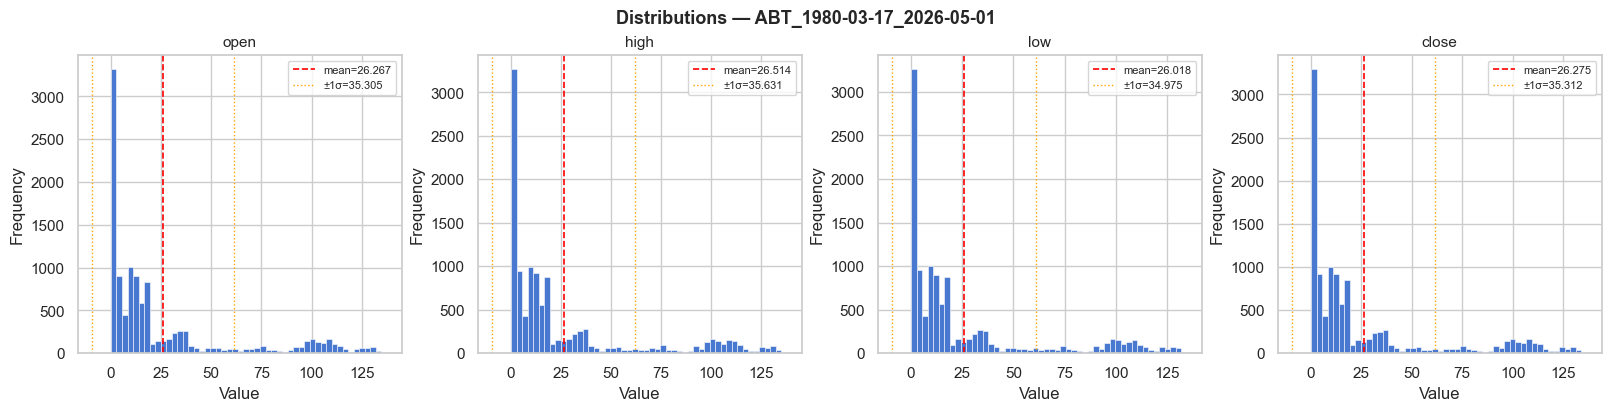

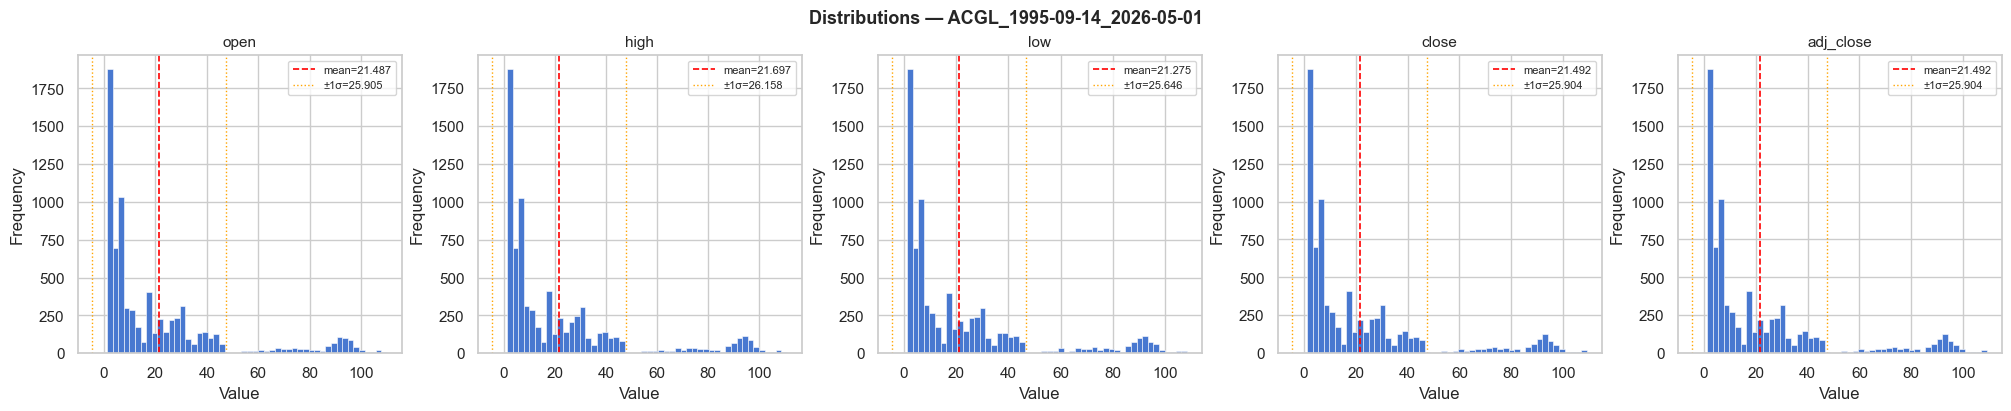

In [43]:
plot_items = list(dataframes.items())
if MAX_FILES_DISPLAY is not None:
    plot_items = plot_items[:MAX_FILES_DISPLAY]

for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.empty:
        continue

    n_cols = len(num_df.columns)
    fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
    if n_cols == 1:
        axes = [axes]

    for ax, col in zip(axes, num_df.columns):
        data = num_df[col].dropna()
        ax.hist(data, bins=50, edgecolor='white', linewidth=0.4)
        mu, sigma = data.mean(), data.std()
        ax.axvline(mu, color='red',    linestyle='--', linewidth=1.2, label=f'mean={mu:.3f}')
        ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.0)
        ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.0, label=f'\u00b11\u03c3={sigma:.3f}')
        ax.set_title(col, fontsize=11)
        ax.set_xlabel('Value')
        ax.set_ylabel('Frequency')
        ax.legend(fontsize=8)

    fig.suptitle(f"Distributions \u2014 {name}", fontsize=13, fontweight='bold')
    plt.show()

### 1.3 Per-File Correlation Matrix
> Limited to the first `MAX_FILES_DISPLAY` files.

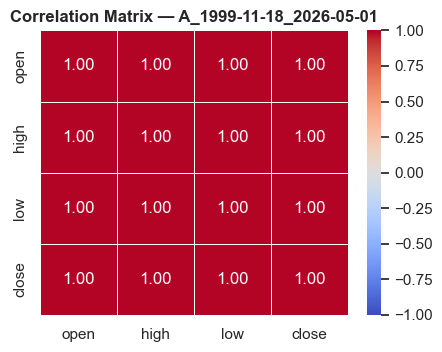

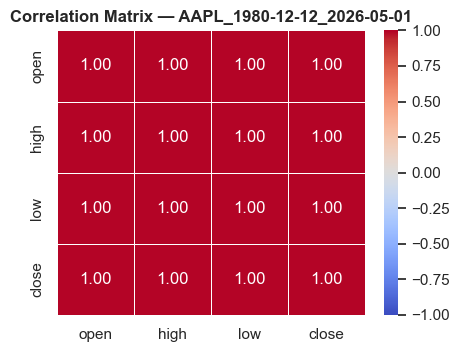

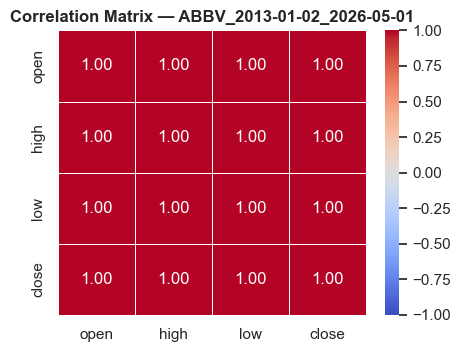

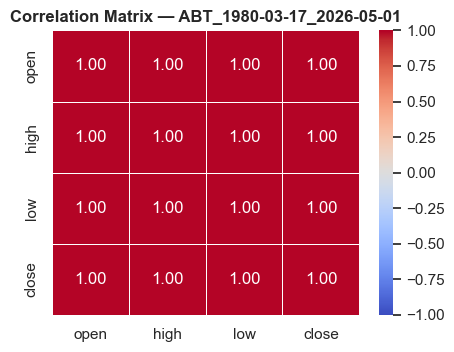

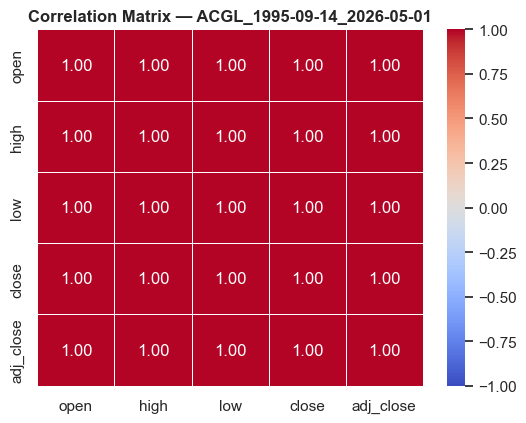

In [44]:
for name, df in plot_items:
    num_df = df.select_dtypes(include='number')
    if num_df.shape[1] < 2:
        print(f"{name}: only one numeric column, correlation skipped.")
        continue

    corr = num_df.corr()
    size = max(4, len(corr) * 0.9 + 1)
    fig, ax = plt.subplots(figsize=(size, size * 0.8))
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
                linewidths=0.5, ax=ax, vmin=-1, vmax=1)
    ax.set_title(f"Correlation Matrix \u2014 {name}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

---
## 2. Aggregate Statistics

Statistics computed over **all files combined** (rows from every CSV concatenated).
The cross-file summary shows per-column statistics averaged across files, giving a
sense of how consistent individual files are relative to the global distribution.

### 2.1 Aggregate Descriptive Statistics

In [45]:
# Build combined dataset on the intersection of numeric columns
common_cols = sorted(
    set.intersection(*[set(df.select_dtypes(include='number').columns)
                       for df in dataframes.values()])
)
combined_df = pd.concat(
    [df[common_cols] for df in dataframes.values()],
    ignore_index=True
)
print(f"Combined dataset: {len(combined_df):,} rows x {len(common_cols)} columns")
print(f"Columns: {common_cols}\n")

# Extended describe
desc   = combined_df.describe()
median = combined_df.median().rename('median')
kurt   = combined_df.kurtosis().rename('kurtosis')
skew   = combined_df.skew().rename('skewness')

agg_stats = pd.concat([desc, median.to_frame().T, kurt.to_frame().T, skew.to_frame().T])
row_order  = ['count', 'mean', 'median', 'std', 'min', '25%', '50%', '75%', 'max', 'kurtosis', 'skewness']
agg_stats  = agg_stats.reindex([r for r in row_order if r in agg_stats.index])

print("Aggregate Descriptive Statistics (all files combined):")
display(agg_stats)

Combined dataset: 3,115,020 rows x 4 columns
Columns: ['close', 'high', 'low', 'open']

Aggregate Descriptive Statistics (all files combined):


,close,high,low,open
count,3115020.0000,3115020.0000,3115020.0000,3115020.0000
mean,52.3701,52.9873,51.7254,52.3615
median,17.4411,17.6741,17.1900,17.4385
std,182.5315,184.7101,180.3405,182.5066
min,0.0014,0.0014,0.0014,0.0014
25%,4.1404,4.1947,4.0838,4.1394
50%,17.4411,17.6741,17.1900,17.4385
75%,49.1098,49.6394,48.5372,49.0919
max,9924.4004,9964.7695,9794.0000,9914.1699
kurtosis,861.9706,861.0454,865.2879,863.1515


### 2.2 Cross-File Summary

Mean and standard deviation of each per-file statistic, grouped by column.
High std values indicate heterogeneity across files.

In [46]:
cross_file = (
    per_file_summary
    .groupby('column')[['mean', 'median', 'std', 'min', 'max', 'kurtosis', 'skewness']]
    .agg(['mean', 'std'])
)
cross_file.columns = [f"{stat}_{agg}" for stat, agg in cross_file.columns]
display(cross_file)

,mean_mean,mean_std,median_mean,median_std,std_mean,std_std,min_mean,min_std,max_mean,max_std,kurtosis_mean,kurtosis_std,skewness_mean,skewness_std
column,,,,,,,,,,,,,,
adj_close,63.4987,59.4066,19.4257,14.1088,95.2370,98.0519,0.6981,0.7124,398.7951,409.5207,1.9496,0.2818,1.7347,0.0031
close,61.3333,94.0892,34.5470,45.5570,66.8112,134.8052,4.5271,7.8186,318.2071,631.8958,2.1545,4.6068,1.4102,0.8671
high,62.1157,95.2767,35.0248,46.3020,67.6315,136.4195,4.6850,8.0542,321.7138,635.4776,2.1647,4.6377,1.4117,0.8695
low,60.5183,92.8588,34.0516,44.7085,65.9572,133.2074,4.3830,7.5217,313.4559,623.1821,2.1348,4.5369,1.4078,0.8629
open,61.3251,94.0568,34.5436,45.5364,66.8083,134.7990,4.5372,7.8154,318.2595,630.8935,2.1518,4.5886,1.4101,0.8663


### 2.3 Aggregate Histograms

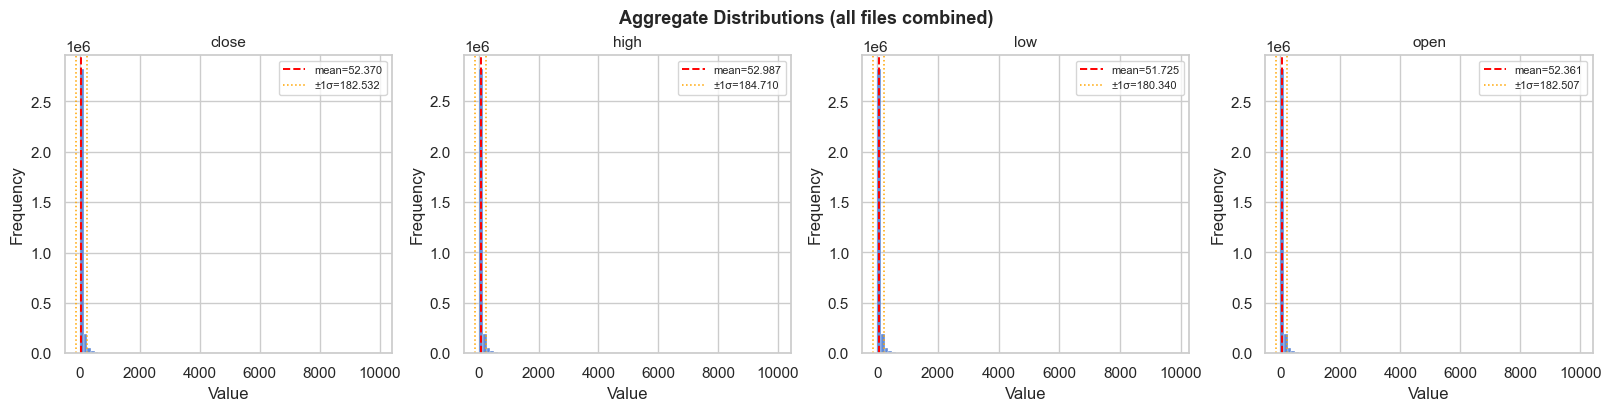

In [47]:
n_cols = len(common_cols)
fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4), constrained_layout=True)
if n_cols == 1:
    axes = [axes]

for ax, col in zip(axes, common_cols):
    data = combined_df[col].dropna()
    ax.hist(data, bins=80, edgecolor='white', linewidth=0.3, alpha=0.85)
    mu, sigma = data.mean(), data.std()
    ax.axvline(mu, color='red',    linestyle='--', linewidth=1.4, label=f'mean={mu:.3f}')
    ax.axvline(mu + sigma, color='orange', linestyle=':',  linewidth=1.1)
    ax.axvline(mu - sigma, color='orange', linestyle=':',  linewidth=1.1, label=f'\u00b11\u03c3={sigma:.3f}')
    ax.set_title(col, fontsize=11)
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

fig.suptitle("Aggregate Distributions (all files combined)", fontsize=13, fontweight='bold')
plt.show()

### 2.4 Aggregate Correlation Matrices

Two complementary views:
- **Left** — correlation computed on the full concatenated dataset
- **Right** — element-wise mean of per-file correlation matrices (preserves within-file structure)

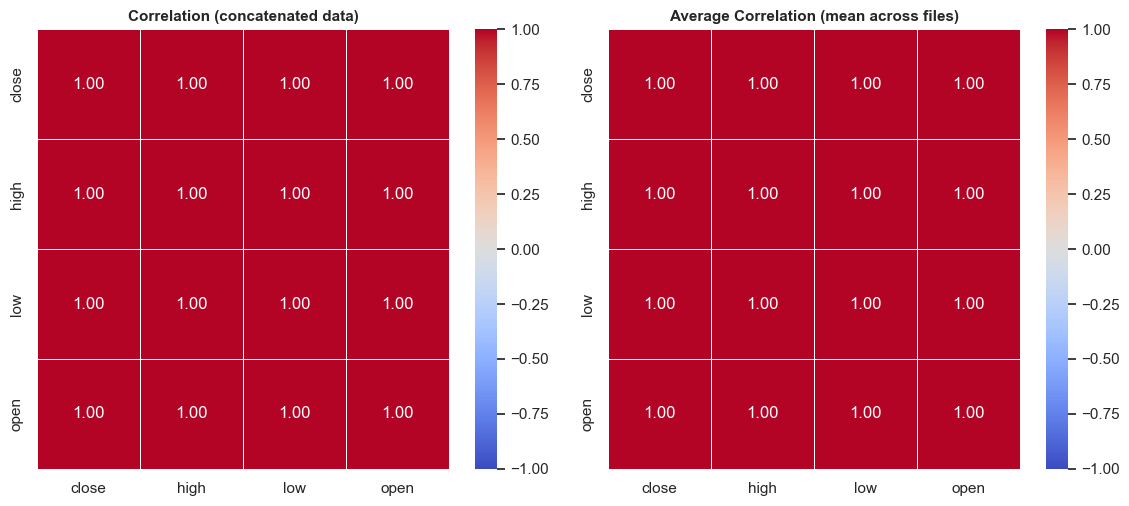

In [48]:
# Per-file correlation matrices stacked
corr_stack = np.array([
    df[common_cols].corr().values
    for df in dataframes.values()
    if df[common_cols].shape[0] > 1
])
avg_corr = pd.DataFrame(corr_stack.mean(axis=0), index=common_cols, columns=common_cols)

size = max(5, len(common_cols) * 1.2 + 1)
fig, axes = plt.subplots(1, 2, figsize=(size * 2, size * 0.9))

# Left: concatenated
corr_combined = combined_df.corr()
sns.heatmap(corr_combined, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Correlation (concatenated data)", fontsize=11, fontweight='bold')

# Right: average across files
sns.heatmap(avg_corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, ax=axes[1], vmin=-1, vmax=1)
axes[1].set_title("Average Correlation (mean across files)", fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()